# D-Wave Ocean SDK Framework with Simulated Annealing

This tutorial outlines how to use the D-Wave Ocean SDK to formulate and solve a QUBO optimization problem using simulated annealing. Simulated annealing runs entirely on the local machine, so no access to the D-Wave Leap quantum cloud service is required.

**If you do have access to the Leap quantum cloud service then check out our tutorial on [solving QUBO problems using a quantum annealer](https://kaufmann-group.github.io/qstep-demo/D-wave%20SDK%20Demonstration%20Quantum%20Annealing.html).**

## Installation & Setup



In this section, we outline how to install the D-Wave Ocean SDK. It is recommended that the Ocean SDK be installed inside a Python virtual environment rather than directly into the system as virtual environments keep the packages used for this project isolated from other Python projects and avoid potential dependency conflicts.

The virtual environment can also be registered as a Jupyter kernel, allowing a Jupyter notebook to run directly inside the same environment in which the Ocean SDK is installed. To create a virtual environment and activate it in macOS or Linux run,

``` bash
python3 -m venv ocean
source ocean/bin/activate
``` 

To create and run a virtual environment in Windows' command shell run,

``` bat
python -m venv ocean
ocean\Scripts\activate.bat
```

Once the environment is activated, any Python packages installed with `pip` will be installed inside the ocean environment rather than globally. To install the Ocean SDK and other libraries that will be used run,

``` bash
python -m pip install --upgrade pip

python -m pip install dwave-ocean-sdk
python -m pip install yfinance 
```

Since this tutorial uses Jupyter notebooks we must register the environment with Jupyter,

``` bash
python -m pip install ipykernel
python -m ipykernel install --user --name ocean --display-name "Ocean Environment"
```

**Note after opening the Jupyter Notebook make sure to select the "Ocean Environment" kernel.**

## Review

Recall that quantum annealers are designed to solve certain classes of optimization problems, one of the most common being [Quadratic Unconstrained Binary Optimization (QUBO)](https://en.wikipedia.org/wiki/Quadratic_unconstrained_binary_optimization) problems. D-Wave's Quantum Processing Unit (QPU) represents these problems using an Ising Hamiltonian of the form

$$H(\mathbf{s}) = \sum_i h_i s_i + \sum_{i<j} J_{ij}s_i s_j,\qquad s_i\in\{-1,+1\},$$

where the coefficients $h_i$ represent individual biases and $J_{ij}$ represent interactions between pairs of spins. Using a simple change of variables between Ising spins and binary variables, typically

$$s_i = 2x_i-1,$$

we can rewrite the same problem as a QUBO,

$$Q(\mathbf{x}) = \sum_i a_i x_i + \sum_{i<j} b_{ij}x_i x_j, \qquad x_i\in\{0,1\}.$$

This allows an optimization problem written as a QUBO to be mapped directly onto the Ising model implemented by the D-Wave hardware. The QPU uses a network of superconducting qubits whose interactions are programmed according to the coefficients of the problem. During quantum annealing, the system is driven toward low-energy configurations of the Ising Hamiltonian. After measurement, these spin configurations can be converted back into binary variables, with the lowest-energy solutions corresponding to minima of the original QUBO objective function. Learn more about the physics of quantum annealing in [this]() notebook!

## Optimization Problem Statement: Markowitz Portfolio Optimization

<div style="display: flex; align-items: center; gap: 30px;">
<div style="flex: 2;">
<p>
A common financial optimization problem is known as the Markowitz mean variance portfolio optimization. It states that given a set of assets with known expected returns and correlations, the goal is to determine how much of a portfolio should be allocated to each asset.
    
It states that an optimal portfolio balances two competing objectives: maximizing expected return while minimizing financial risk. The set of portfolios that provide the best possible return for a given level of risk forms what is known as the efficient frontier.
</p>
</div>

<div style="flex: 1; text-align: center;">
<img src="./images/efficient-frontier.jpg" style="width: 100%; max-width: 300px; height: auto;">
</div>
</div>

Say we have a collection of assets in a portfolio and the variable,

$$\mathbf{w} = \begin{pmatrix} w_1 \\ w_2 \\ \vdots \\ w_N \end{pmatrix}$$

represents the fraction of the portfolio allocated to each asset, where $\mu_i$ is the [expected return](https://en.wikipedia.org/wiki/Expected_return) of asset $i$ and $\Sigma$ is the [covariance matrix](https://en.wikipedia.org/wiki/Covariance_matrix) describing the risk and correlations between assets. The expected of the portfolio is given by the expression,

$$\boldsymbol{\mu}^{T}\mathbf{w},$$

while the portfolio variance, which is used as a [measure of risk](https://en.wikipedia.org/wiki/Risk_measure), is given by the expression,

$$\mathbf{w}^{T}\Sigma\mathbf{w}.$$

The optimization problem can therefore be written as

$$\min_{\mathbf{w}} \left[ \lambda_1 \mathbf{w}^{T}\Sigma\mathbf{w} - \lambda_2 \boldsymbol{\mu}^{T}\mathbf{w} \right],$$

where the first term penalizes portfolio risk and the second term rewards expected return. In this optimization problem we also require the entire portfolio to be allocated, or simply put the weights must sum to $1$.

$$\sum_i w_i = 1$$

Because a QUBO is an unconstrained optimization problem, this condition can be included using a quadratic penalty,

$$\lambda_3 \left( \sum_i w_i - 1 \right)^2.$$

Therefore complete objective function we seek to mimize becomes,

$$H(\mathbf{w}) = \lambda_1 \mathbf{w}^{T}\Sigma\mathbf{w} - \lambda_2 \boldsymbol{\mu}^{T}\mathbf{w} + \lambda_3 \left( \sum_i w_i - 1 \right)^2.$$

Here, $\lambda_1$ controls the importance of expected return, $\lambda_2$ controls the penalty associated with portfolio risk and  $\lambda_3$ controls the portfolio normalization constraint. Something worth noting is that the portfolio weights $w_i$ are continuous variables, while a QUBO requires binary variables. So to represent each portfolio weight using several binary variables we look at its binary expansion

$$w_i = \sum_{k=0}^{b-1} \frac{2^k}{2^b -1}x_{ik}, \quad x_{ik}\in\{0,1\}.$$

Substituting these binary representations into the objective converts the portfolio optimization problem into a quadratic function of binary variables,

$$H(\mathbf{x})=\mathbf{x}^{T}Q\mathbf{x}.$$


## Yahoo Finiance Data

For this demonstration we get the average returns from Yahoo Finiance from the `yfinance` library (ensure it is installed in this virtual environment). A full list of the assets accessable are given [here](assets.txt). 

In [50]:
import yfinance as yf

assets = ["AAPL", "MSFT", "NVDA", "CSCO", "ORCL", "QCOM", "IBM"]

start="2025-04-04"
end="2026-04-04"

data = yf.download(assets, start=start, end=end)
closing_prices = data["Close"].pct_change().dropna()

# The 252 represents the number of business days in a year
returns = closing_prices.mean() * 252 
covariance = closing_prices.cov() * 252

[*********************100%***********************]  7 of 7 completed


## Using Ocean's Simulated Annealing Sampler

The 

In [51]:
from collections import defaultdict

Q = defaultdict(float)

lambda_1 = 1.0    # Portfolio risk 
lambda_2 = 100.0  # Budget constraint
lambda_3 = 1.0    # Expected return


bits_per_asset = 12

# Binary coefficients used to represent each portfolio weight: ~ 1/2, ~ 1/4, ~1/8, ... 
bit_weights = [2**k / (2**bits_per_asset - 1) for k in range(bits_per_asset)]

This loop enumerates the binary variables of the encoding. For each asset $i \in \{1,\dots,n\}$ and each bit index $k \in \{0,\dots,b-1\}$, it registers the variable $x_{ik}$ together with the asset it belongs to and its associated coefficient $c_k$, where

$$w_i = \sum_{k=0}^{b-1} c_k\,x_{ik}, \qquad c_k = \frac{2^k}{2^b-1}.$$

This yields a total of $nb$ binary variables. Storing each variable alongside its asset index and coefficient allows the subsequent construction of the QUBO matrix to retrieve $\mu_i$, $\sigma_{ij}$ and $c_k$ directly, without re-deriving them from the variable labels.

In [ ]:
variables = []

for asset in assets:
    for k in range(bits_per_asset):
        variable = f"{asset}_{k}"
        coefficient = bit_weights[k]

        variables.append((variable, asset, coefficient))

This loop assigns the diagonal entries of the QUBO matrix. Since $x_{ik}^2 = x_{ik}$ for binary variables, every squared term collapses to a linear one and lands on the diagonal:

$$Q[(ik,ik)] = \lambda_3\,\sigma_{ii}c_k^2 \;-\; \lambda_2\,\mu_i c_k \;+\; \lambda_1\left(c_k^2 - 2c_k\right).$$

The three contributions come from the risk term, the expected return, which is linear and so appears only here, and the budget penalty. The constant $\lambda_1$ left over from expanding the penalty carries no variables and is omitted, as it shifts every energy equally and does not change the minimizer.

In [ ]:
for variable, asset, coefficient in variables:
    mu_i = returns.loc[asset]
    sigma_ii = covariance.loc[asset, asset]

    Q[(variable, variable)] += (lambda_3 * sigma_ii * coefficient**2 - lambda_2 * mu_i * coefficient + lambda_1 * (coefficient**2 - 2 * coefficient))

This loop assigns the off-diagonal entries of the QUBO matrix. The inner index begins at $a+1$ so that each unordered pair is visited exactly once, with the factor of $2$ absorbing the symmetric counterpart:

$$Q[(ik,jl)] = 2\,c_k c_l\left(\lambda_3\,\sigma_{ij} + \lambda_1\right).$$

The two contributions come from the cross terms of $\mathbf{w}^\top\Sigma\mathbf{w}$ and of the budget penalty; the expected return, being linear, contributes nothing here. Pairs with $i = j$ are included, since $\sigma_{ij}$ then reduces to the variance $\sigma_{ii}$ and these terms form part of the risk of a single asset.

In [44]:
for a in range(len(variables)):
    variable_i, asset_i, coefficient_i = variables[a]

    for b in range(a + 1, len(variables)):

        variable_j, asset_j, coefficient_j = variables[b]
        sigma_ij = covariance.loc[asset_i, asset_j]

        Q[(variable_i, variable_j)] += (2 * coefficient_i * coefficient_j * ( lambda_3 * sigma_ij + lambda_1 ))


Q = dict(Q)

Because simulated annealing runs on a classical computer rather than on a QPU, there is no hardware graph to map the problem onto and no minor embedding step. Any QUBO can be passed to the sampler directly, regardless of how its variables are connected.

Simulated annealing mimics the physical annealing process. Each run starts from a random configuration at a high effective temperature, where moves that increase the energy are often accepted, and the temperature is then lowered over a series of sweeps so that the search gradually settles into a low-energy configuration. Ocean provides this through `SimulatedAnnealingSampler`, which is part of the `dwave-samplers` package included in the Ocean SDK.

In [45]:
from dwave.samplers import SimulatedAnnealingSampler

sampler = SimulatedAnnealingSampler()

sampleset = sampler.sample_qubo(Q, num_reads=1000)

best = sampleset.first # returns lowest energy sample in the SampleSet
solution = dict(best.sample)  

print("Solution (binary representation of weights):")

# Prints the binary output in a readable format 
for asset in assets:
    bits = "".join(str(solution[f"{asset}_{k}"]) for k in reversed(range(bits_per_asset)))
    print(f"  {asset:<10} {bits}")

print("Energy:", best.energy)

Solution (binary representation of weights):
  AAPL       000011001111
  MSFT       000100000000
  NVDA       110001111111
  CSCO       000101111111
  ORCL       000000100011
  QCOM       000000000000
  IBM        000000010001
Energy: -100.50933091360253


Solving for the weights gives the following graph.

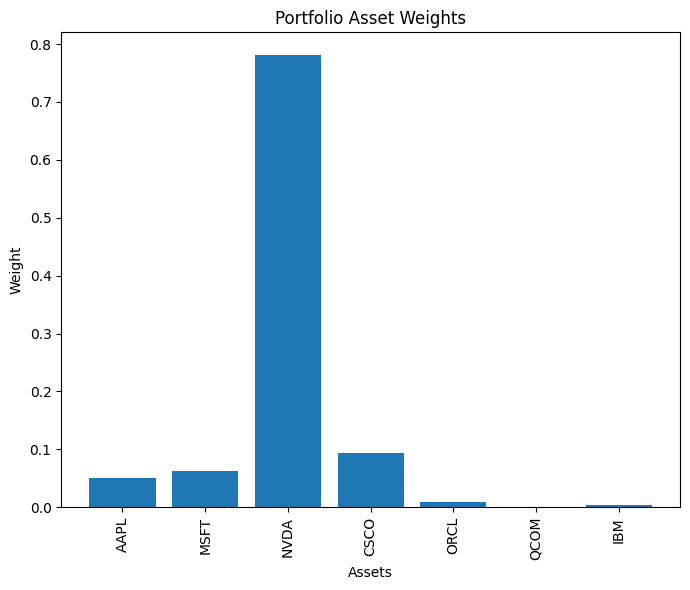

In [46]:
import matplotlib.pyplot as plt

portfolio = {}

for asset in assets:
    portfolio[asset] = sum(bit_weights[k] * solution[f"{asset}_{k}"] for k in range(bits_per_asset))

plt.figure(figsize=(7, 6))
plt.bar(portfolio.keys(), portfolio.values())

plt.title("Portfolio Asset Weights")
plt.xlabel("Assets")
plt.ylabel("Weight")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Finished? Check out our other tutorials! 

<a class="notebook-download"
   href="https://github.com/kaufmann-group/qstep-demo/raw/refs/heads/main/D-wave%20Simulated%20Annealing%20Demonstration.ipynb"
   download>
   Download notebook ↓
</a>